In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [2]:
# =========================
# LOAD DATA
# =========================
data_path = "../data/processed/"

train_df = pd.read_excel(os.path.join(data_path, "train.xlsx"))
dev_df   = pd.read_excel(os.path.join(data_path, "dev.xlsx"))
test_df  = pd.read_excel(os.path.join(data_path, "test.xlsx"))

X_train_raw = train_df["clean_review"]
y_train = train_df["label"]

X_dev_raw = dev_df["clean_review"]
y_dev = dev_df["label"]

X_test_raw = test_df["clean_review"]
y_test = test_df["label"]

print("Train size:", len(X_train_raw))
print("Dev size:", len(X_dev_raw))
print("Test size:", len(X_test_raw))

Train size: 20762
Dev size: 4455
Test size: 4438


In [3]:
# =========================
# LOAD STOPWORDS
# =========================
stopwords_path = os.path.join("..", "dicts", "vietnamese-stopwords.txt")

with open(stopwords_path, "r", encoding="utf-8") as f:
    stopwords = set([line.strip() for line in f])

print("Number of stopwords:", len(stopwords))

Number of stopwords: 1942


In [4]:
# =========================
# PREPROCESS FUNCTION
# =========================
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Tách từ (underthesea)
    text = word_tokenize(text, format="text")
    
    # 2. Xóa stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords]
    
    return " ".join(tokens)

In [5]:
# =========================
# APPLY PREPROCESSING
# =========================
X_train = X_train_raw.apply(preprocess_text)
X_dev   = X_dev_raw.apply(preprocess_text)
X_test  = X_test_raw.apply(preprocess_text)

# Xem thử kết quả
print("Before:", X_train_raw.iloc[0])
print("After :", X_train.iloc[0])

Before: đèn như c lắp không quảng cáo lắp xe c về lắp đéo vừa làm ăn như ứt
After : đèn c_lắp quảng_cáo lắp xe c lắp_đéo làm_ăn ứt


In [6]:
# =========================
# TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    norm='l2'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf   = vectorizer.transform(X_dev)
X_test_tfidf  = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (20762, 20000)


In [7]:
# =========================
# NAIVE BAYES
# =========================
nb_params = {"alpha": [0.01, 0.1, 0.5, 1.0]}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

nb_grid.fit(X_train_tfidf, y_train)
nb_best = nb_grid.best_estimator_

print("Best NB params:", nb_grid.best_params_)

Best NB params: {'alpha': 0.1}


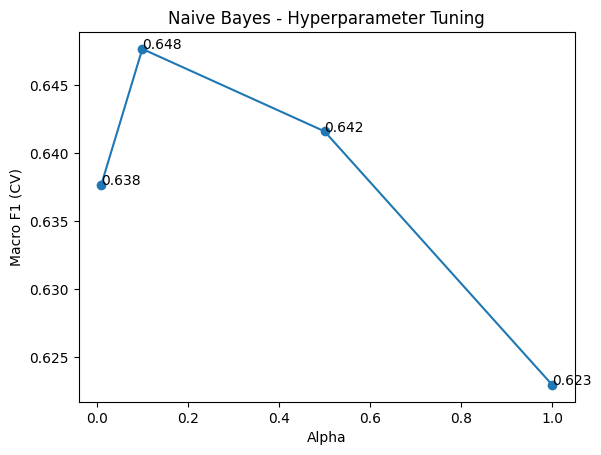

In [8]:
# =========================
# VISUALIZE NB
# =========================
import matplotlib.pyplot as plt

alphas = nb_grid.cv_results_['param_alpha'].data
scores = nb_grid.cv_results_['mean_test_score']

plt.figure()
plt.plot(alphas, scores, marker='o')

plt.xlabel("Alpha")
plt.ylabel("Macro F1 (CV)")
plt.title("Naive Bayes - Hyperparameter Tuning")

for i in range(len(alphas)):
    plt.text(alphas[i], scores[i], f"{scores[i]:.3f}")

plt.show()

In [9]:

# =========================
# SVM
# =========================
svm_params = {"C": [0.1, 1, 10]}

svm_grid = GridSearchCV(
    LinearSVC(),
    svm_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)
svm_best = svm_grid.best_estimator_

print("Best SVM params:", svm_grid.best_params_)


Best SVM params: {'C': 1}


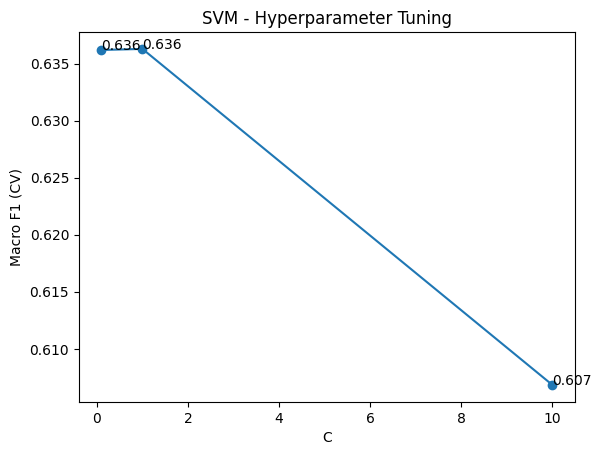

In [14]:
# =========================
# VISUALIZE SVM
# =========================
C_values = svm_grid.cv_results_['param_C'].data
scores = svm_grid.cv_results_['mean_test_score']

plt.figure()
plt.plot(C_values, scores, marker='o')

plt.xlabel("C")
plt.ylabel("Macro F1 (CV)")
plt.title("SVM - Hyperparameter Tuning")

for i in range(len(C_values)):
    plt.text(C_values[i], scores[i], f"{scores[i]:.3f}")

plt.show()

In [16]:
# =========================
# RANDOM FOREST
# =========================
rf_params = {
    "n_estimators": [20, 50, 100, 200],
    "max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train_tfidf, y_train)
rf_best = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)

Best RF params: {'max_depth': None, 'n_estimators': 50}


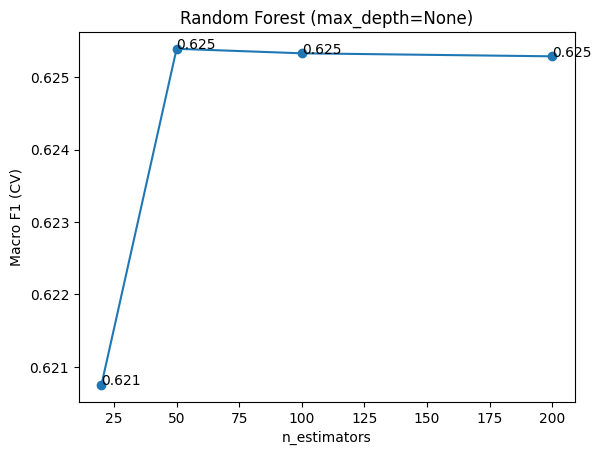

In [17]:
# =========================
# VISUALIZE RANDOM FOREST 
# =========================
results = pd.DataFrame(rf_grid.cv_results_)

# lọc max_depth = None (thực chất là NaN)
filtered = results[results['param_max_depth'].isna()]

# convert kiểu dữ liệu
n_estimators = filtered['param_n_estimators'].astype(int)
scores = filtered['mean_test_score']

plt.figure()
plt.plot(n_estimators, scores, marker='o')

plt.xlabel("n_estimators")
plt.ylabel("Macro F1 (CV)")
plt.title("Random Forest (max_depth=None)")

for i in range(len(n_estimators)):
    plt.text(n_estimators.iloc[i], scores.iloc[i], f"{scores.iloc[i]:.3f}")

plt.show()

In [18]:
# =========================
# PROFESSIONAL EVALUATION FUNCTION
# =========================
def evaluate(model, X, y, name="Model"):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred, average="macro")

    # Title đẹp
    display(Markdown(f"## {name} Evaluation"))

    # ===== Summary Table =====
    summary_df = pd.DataFrame({
        "Metric": ["Accuracy", "Macro F1"],
        "Score": [round(acc, 4), round(f1, 4)]
    })

    display(summary_df.style.set_caption("Overall Performance"))

    # ===== Classification Report =====
    report = classification_report(y, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    display(report_df.style
            .set_caption("Classification Report")
            .format("{:.4f}"))

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y, y_pred)

    labels = sorted(list(set(y)))  # hoặc tự set: ["Negative","Neutral","Positive"]

    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.show()

## Naive Bayes (Dev) Evaluation

,Metric,Score
0,Accuracy,0.696100
1,Macro F1,0.667300


,precision,recall,f1-score,support
0,0.7159,0.7324,0.7241,1562.0000
1,0.5337,0.4527,0.4899,1120.0000
2,0.7604,0.8178,0.7880,1773.0000
accuracy,0.6961,0.6961,0.6961,0.6961
macro avg,0.6700,0.6676,0.6673,4455.0000
weighted avg,0.6878,0.6961,0.6906,4455.0000


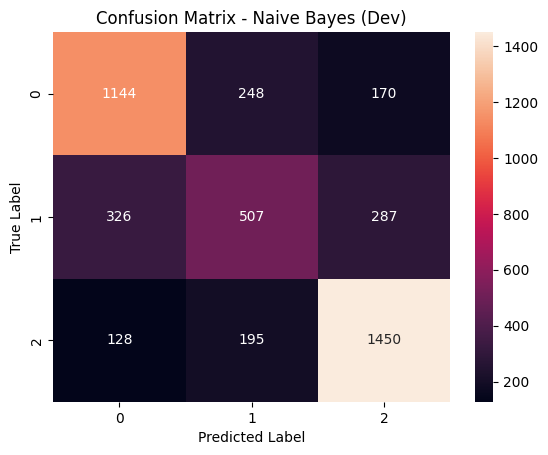

In [19]:
# =========================
# EVALUATE ON DEV
# =========================
evaluate(nb_best, X_dev_tfidf, y_dev, "Naive Bayes (Dev)")

## SVM (Dev) Evaluation

,Metric,Score
0,Accuracy,0.690900
1,Macro F1,0.660500


,precision,recall,f1-score,support
0,0.7010,0.7458,0.7227,1562.0000
1,0.5408,0.4321,0.4804,1120.0000
2,0.7529,0.8060,0.7785,1773.0000
accuracy,0.6909,0.6909,0.6909,0.6909
macro avg,0.6649,0.6613,0.6605,4455.0000
weighted avg,0.6814,0.6909,0.6840,4455.0000


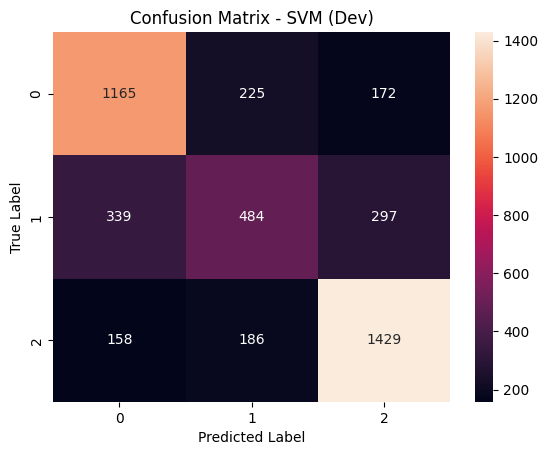

In [20]:
evaluate(svm_best, X_dev_tfidf, y_dev, "SVM (Dev)")

## Random Forest (Dev) Evaluation

,Metric,Score
0,Accuracy,0.687100
1,Macro F1,0.643600


,precision,recall,f1-score,support
0,0.6824,0.7663,0.7220,1562.0000
1,0.5997,0.3438,0.4370,1120.0000
2,0.7183,0.8342,0.7719,1773.0000
accuracy,0.6871,0.6871,0.6871,0.6871
macro avg,0.6668,0.6481,0.6436,4455.0000
weighted avg,0.6759,0.6871,0.6702,4455.0000


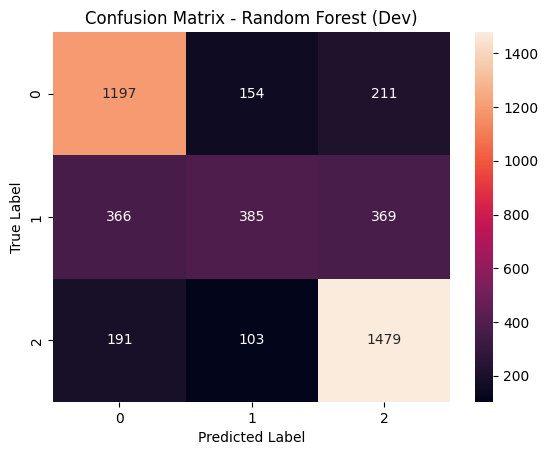

In [21]:
evaluate(rf_best, X_dev_tfidf, y_dev, "Random Forest (Dev)")

## Naive Bayes (Test) Evaluation

,Metric,Score
0,Accuracy,0.674900
1,Macro F1,0.642600


,precision,recall,f1-score,support
0,0.6853,0.7248,0.7045,1559.0000
1,0.5006,0.4073,0.4492,1117.0000
2,0.7500,0.8002,0.7743,1762.0000
accuracy,0.6749,0.6749,0.6749,0.6749
macro avg,0.6453,0.6441,0.6426,4438.0000
weighted avg,0.6645,0.6749,0.6679,4438.0000


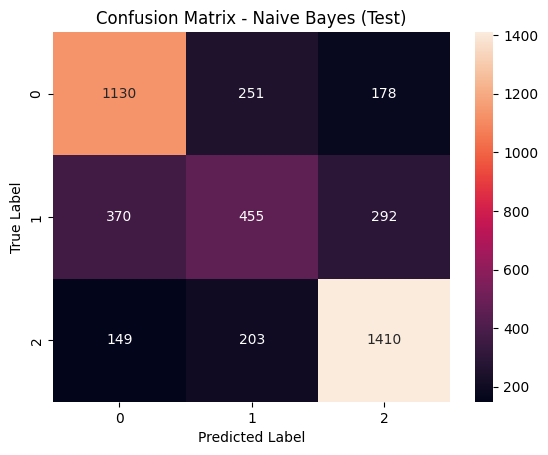

In [22]:
# =========================
# EVALUATE ON TEST
# =========================
evaluate(nb_best, X_test_tfidf, y_test, "Naive Bayes (Test)")

## SVM (Test) Evaluation

,Metric,Score
0,Accuracy,0.667900
1,Macro F1,0.634200


,precision,recall,f1-score,support
0,0.6714,0.7300,0.6994,1559.0000
1,0.4971,0.3894,0.4367,1117.0000
2,0.7446,0.7894,0.7664,1762.0000
accuracy,0.6679,0.6679,0.6679,0.6679
macro avg,0.6377,0.6363,0.6342,4438.0000
weighted avg,0.6566,0.6679,0.6599,4438.0000


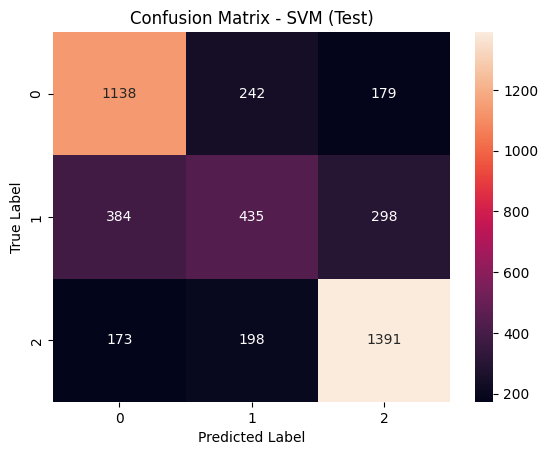

In [23]:
evaluate(svm_best, X_test_tfidf, y_test, "SVM (Test)")

## Random Forest (Test) Evaluation

,Metric,Score
0,Accuracy,0.673100
1,Macro F1,0.627900


,precision,recall,f1-score,support
0,0.6714,0.7601,0.7130,1559.0000
1,0.5748,0.3232,0.4138,1117.0000
2,0.7046,0.8178,0.7570,1762.0000
accuracy,0.6731,0.6731,0.6731,0.6731
macro avg,0.6503,0.6337,0.6279,4438.0000
weighted avg,0.6603,0.6731,0.6552,4438.0000


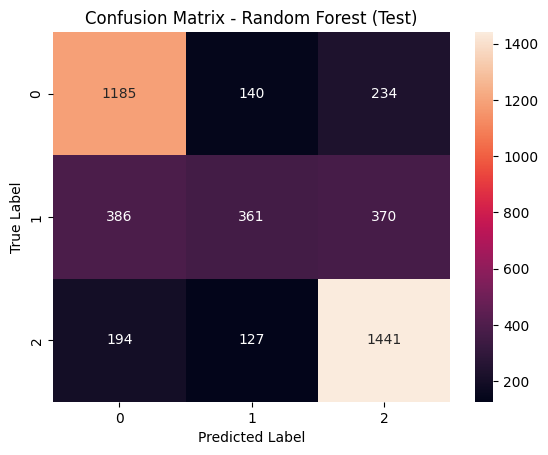

In [24]:
evaluate(rf_best, X_test_tfidf, y_test, "Random Forest (Test)")

In [25]:
# =========================
# COMPARISON TABLE
# =========================
results = []

models = {
    "Naive Bayes": nb_best,
    "SVM": svm_best,
    "Random Forest": rf_best
}

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro")
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1, 4)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Accuracy,Macro F1
0,Naive Bayes,0.6749,0.6426
1,SVM,0.6679,0.6342
2,Random Forest,0.6731,0.6279


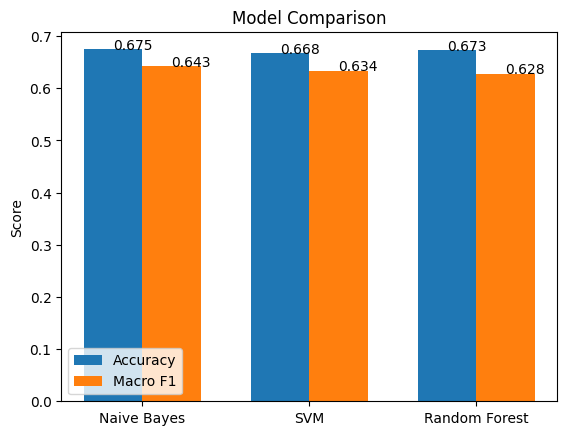

In [26]:
models = results_df["Model"]
accuracy = results_df["Accuracy"]
f1_scores = results_df["Macro F1"]

x = np.arange(len(models))
width = 0.35

plt.figure()

plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="Macro F1")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison")

# Hiển thị số
for i in range(len(models)):
    plt.text(x[i] - width/2, accuracy[i], f"{accuracy[i]:.3f}")
    plt.text(x[i] + width/2, f1_scores[i], f"{f1_scores[i]:.3f}")

plt.legend()
plt.show()

In [ ]:
# =========================
# SAVE RESULTS
# =========================
results_df.to_excel("model_comparison.xlsx", index=False)